## Application 1: estimator comparison tables/figures

In [ ]:
from pathlib import Path
import sys

# --- Resolve repo root (works whether you run from repo root or within notebooks/) ---
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    if (REPO_ROOT.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent
    elif (REPO_ROOT.parent.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import display
from notebooks.set_up import (
    ensure_dirs,
    TABLE_DIR, FIG_DIR,
    CATE_DIR, 
)

ensure_dirs()

# Inputs
output_result = str(CATE_DIR) + "/"

# Outputs
output_table = TABLE_DIR

output_figure = FIG_DIR

# For legacy code that uses string concatenation:
output_table = str(output_table) + "/"
output_figure = str(output_figure) + "/" 


# Create and save Latex tables for Application 1

In [0]:
# import summary tables for Application 1
import pandas as pd
file_names = ["summary_results_rmse.csv", "summary_biased_results_rmse.csv"]

excel_tables = [pd.read_csv(output_result + fn) for fn in file_names]

display(excel_tables[0])

estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_rmse,ate_bias_mean,ate_bias_sd,ate_stderr_mean,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean
BayesianCausalForest,50,258.679,9.454,0.01,-0.004,0.01,0.01,0.9,0.024,0.003,0.914
CausalForest,50,25.133,1.683,0.009,0.0,0.009,0.009,0.94,0.036,0.004,0.871
GbrDML,50,268.091,10.657,0.01,0.0,0.01,0.113,1.0,0.126,0.008,0.825
GbrDR,50,274.026,10.832,0.01,0.002,0.01,0.125,1.0,0.14,0.012,0.815
LassoDML,50,229.891,10.126,0.009,-0.0,0.01,0.008,0.88,0.026,0.007,0.369
LassoDR,50,234.455,10.61,0.01,0.002,0.01,0.009,0.88,0.026,0.006,0.398
LinearDML,50,2.188,0.095,0.009,-0.001,0.009,0.009,0.96,0.046,0.006,0.898
LinearDR,50,2.256,0.13,0.01,0.002,0.01,0.046,1.0,0.051,0.008,0.92
XLearner-GBR,50,160.444,4.439,0.024,-0.022,0.011,0.085,1.0,0.096,0.007,0.819
XLearner-Linear,50,118.399,4.07,0.024,-0.022,0.01,0.036,1.0,0.034,0.006,0.82


In [0]:
# For unbiased scenario: Create a table including runtime (sd), ATE coverage, and CATE coverage
time_coverage = excel_tables[0]
# Revise the table fomrat
time_coverage["Runtime (s , SD)"] = time_coverage["runtime_mean_sec"].round(1).astype(str) + " (" + time_coverage["runtime_sd_sec"].round(1).astype(str) + ")"
time_coverage = time_coverage.rename(columns={"estimator": "Estimator", "ate_rmse": "ATE RMSE","ate_stderr_mean": "Mean ATE SE", "ate_coverage": "ATE Coverage", "cate_coverage_mean": "Mean CATE Coverage"})
# Change the estimator names correspondingly
time_coverage["Estimator"] = time_coverage["Estimator"].replace(
    {"BayesianCausalForest": "Bayesian Causal Forest", "CausalForest": "Causal Forest", "GbrDML": "GBR DML", "GbrDR": "GBR DR-Learner", "LassoDML": "Lasso DML", "LassoDR": "Lasso DR-Learner", "LinearDML": "Standard Linear DML", "LinearDR": "Standard Linear DR-Learner", "XLearner-GBR": "GBR X-Learner", "XLearner-Linear": "Lasso X-Learner"}
)
estimator_order = [
    "Bayesian Causal Forest",
    "Causal Forest",
    "Standard Linear DML",
    "Lasso DML",
    "GBR DML",
    "Standard Linear DR-Learner",
    "Lasso DR-Learner",
    "GBR DR-Learner",
    "Lasso X-Learner",
    "GBR X-Learner"
]
time_coverage["estimator_order"] = time_coverage["Estimator"].apply(lambda x: estimator_order.index(x) if x in estimator_order else -1)
time_coverage = time_coverage.sort_values("estimator_order").drop(columns="estimator_order").reset_index(drop=True)
display(time_coverage)
# save a tex table including only runtime (sd), ATE coverage, and CATE coverage
# Select and round columns first
time_coverage_latex = time_coverage.copy()
time_coverage_latex["ATE Coverage"] = time_coverage_latex["ATE Coverage"].round(2)
time_coverage_latex["Mean CATE Coverage"] = time_coverage_latex["Mean CATE Coverage"].round(2)
time_coverage_latex["Mean ATE SE"] = time_coverage_latex["Mean ATE SE"].round(3)
time_coverage_latex["ATE RMSE"] = time_coverage_latex["ATE RMSE"].round(3)
time_coverage_latex = time_coverage_latex[["Estimator", "Runtime (s , SD)", "ATE RMSE", "Mean ATE SE", "ATE Coverage", "Mean CATE Coverage"]]

latex = time_coverage_latex.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrr"
)
display(time_coverage_latex)
# with open(output_table + "est_coverage.tex", "w", encoding="utf-8") as f:
#     f.write(latex)

Estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ATE RMSE,ate_bias_mean,ate_bias_sd,Mean ATE SE,ATE Coverage,cate_rmse_mean,cate_rmse_sd,Mean CATE Coverage,"Runtime (s , SD)"
Bayesian Causal Forest,50,258.679,9.454,0.01,-0.004,0.01,0.01,0.9,0.024,0.003,0.914,258.7 (9.5)
Causal Forest,50,25.133,1.683,0.009,0.0,0.009,0.009,0.94,0.036,0.004,0.871,25.1 (1.7)
Standard Linear DML,50,2.188,0.095,0.009,-0.001,0.009,0.009,0.96,0.046,0.006,0.898,2.2 (0.1)
Lasso DML,50,229.891,10.126,0.009,-0.0,0.01,0.008,0.88,0.026,0.007,0.369,229.9 (10.1)
GBR DML,50,268.091,10.657,0.01,0.0,0.01,0.113,1.0,0.126,0.008,0.825,268.1 (10.7)
Standard Linear DR-Learner,50,2.256,0.13,0.01,0.002,0.01,0.046,1.0,0.051,0.008,0.92,2.3 (0.1)
Lasso DR-Learner,50,234.455,10.61,0.01,0.002,0.01,0.009,0.88,0.026,0.006,0.398,234.5 (10.6)
GBR DR-Learner,50,274.026,10.832,0.01,0.002,0.01,0.125,1.0,0.14,0.012,0.815,274.0 (10.8)
Lasso X-Learner,50,118.399,4.07,0.024,-0.022,0.01,0.036,1.0,0.034,0.006,0.82,118.4 (4.1)
GBR X-Learner,50,160.444,4.439,0.024,-0.022,0.011,0.085,1.0,0.096,0.007,0.819,160.4 (4.4)


/root/.ipykernel/10293/command-6896129444291440-579534672:34: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = time_coverage_latex.to_latex(


Estimator,"Runtime (s , SD)",ATE RMSE,Mean ATE SE,ATE Coverage,Mean CATE Coverage
Bayesian Causal Forest,258.7 (9.5),0.01,0.01,0.9,0.91
Causal Forest,25.1 (1.7),0.009,0.009,0.94,0.87
Standard Linear DML,2.2 (0.1),0.009,0.009,0.96,0.9
Lasso DML,229.9 (10.1),0.009,0.008,0.88,0.37
GBR DML,268.1 (10.7),0.01,0.113,1.0,0.82
Standard Linear DR-Learner,2.3 (0.1),0.01,0.046,1.0,0.92
Lasso DR-Learner,234.5 (10.6),0.01,0.009,0.88,0.4
GBR DR-Learner,274.0 (10.8),0.01,0.125,1.0,0.82
Lasso X-Learner,118.4 (4.1),0.024,0.036,1.0,0.82
GBR X-Learner,160.4 (4.4),0.024,0.085,1.0,0.82


In [0]:
# For biased scenario: Create a table including runtime (sd), ATE coverage, and CATE coverage
time_coverage_biased = excel_tables[1]
# Revise the table format
time_coverage_biased["Runtime (s , SD)"] = time_coverage_biased["runtime_mean_sec"].round(1).astype(str) + " (" + time_coverage_biased["runtime_sd_sec"].round(1).astype(str) + ")"
time_coverage_biased = time_coverage_biased.rename(columns={"estimator": "Estimator", "ate_rmse": "ATE RMSE", "ate_stderr_mean": "Mean ATE SE", "ate_coverage": "ATE Coverage", "cate_coverage_mean": "Mean CATE Coverage"})
# Change the estimator names correspondingly
time_coverage_biased["Estimator"] = time_coverage_biased["Estimator"].replace(
    {"BayesianCausalForest": "Bayesian Causal Forest", "CausalForest": "Causal Forest", "GbrDML": "GBR DML", "GbrDR": "GBR DR-Learner", "LassoDML": "Lasso DML", "LassoDR": "Lasso DR-Learner", "LinearDML": "Standard Linear DML", "LinearDR": "Standard Linear DR-Learner", "XLearner-GBR": "GBR X-Learner", "XLearner-Linear": "Lasso X-Learner"}
)
time_coverage_biased["estimator_order"] = time_coverage_biased["Estimator"].apply(lambda x: estimator_order.index(x) if x in estimator_order else -1)
time_coverage_biased = time_coverage_biased.sort_values("estimator_order").drop(columns="estimator_order").reset_index(drop=True)
display(time_coverage_biased)
# save a tex table including only runtime (sd), ATE coverage, and CATE coverage
# Select and round columns first
time_coverage_biased_latex = time_coverage_biased.copy()
time_coverage_biased_latex["ATE Coverage"] = time_coverage_biased_latex["ATE Coverage"].round(2)
time_coverage_biased_latex["Mean CATE Coverage"] = time_coverage_biased_latex["Mean CATE Coverage"].round(2)
time_coverage_biased_latex["Mean ATE SE"] = time_coverage_biased_latex["Mean ATE SE"].round(3)
time_coverage_biased_latex["ATE RMSE"] = time_coverage_biased_latex["ATE RMSE"].round(3)
time_coverage_biased_latex = time_coverage_biased_latex[["Estimator", "Runtime (s , SD)", "ATE RMSE", "Mean ATE SE", "ATE Coverage", "Mean CATE Coverage"]]

latex = time_coverage_biased_latex.to_latex(
    index=False,
    escape=False,
    column_format="lrrrrr"
)
display(time_coverage_biased_latex)
# with open(output_table + "est_coverage_biased.tex", "w", encoding="utf-8") as f:
#     f.write(latex)

Estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ATE RMSE,ate_bias_mean,ate_bias_sd,Mean ATE SE,ATE Coverage,cate_rmse_mean,cate_rmse_sd,Mean CATE Coverage,"Runtime (s , SD)"
Bayesian Causal Forest,50,260.604,9.557,0.023,0.021,0.01,0.011,0.48,0.033,0.007,0.855,260.6 (9.6)
Causal Forest,50,25.283,1.797,0.027,0.026,0.008,0.009,0.18,0.044,0.006,0.799,25.3 (1.8)
Standard Linear DML,50,2.143,0.069,0.026,0.025,0.009,0.009,0.24,0.06,0.009,0.837,2.1 (0.1)
Lasso DML,50,224.981,7.9,0.025,0.024,0.009,0.01,0.28,0.037,0.009,0.262,225.0 (7.9)
GBR DML,50,262.752,7.683,0.026,0.025,0.009,0.125,1.0,0.14,0.009,0.826,262.8 (7.7)
Standard Linear DR-Learner,50,2.201,0.08,0.028,0.027,0.01,0.046,1.0,0.064,0.009,0.852,2.2 (0.1)
Lasso DR-Learner,50,230.517,8.435,0.028,0.027,0.01,0.008,0.14,0.041,0.009,0.247,230.5 (8.4)
GBR DR-Learner,50,269.748,7.323,0.028,0.027,0.01,0.132,1.0,0.153,0.012,0.813,269.7 (7.3)
Lasso X-Learner,50,116.444,3.837,0.008,-0.001,0.008,0.035,1.0,0.04,0.008,0.855,116.4 (3.8)
GBR X-Learner,50,158.592,4.332,0.009,-0.001,0.009,0.088,1.0,0.1,0.011,0.829,158.6 (4.3)


/root/.ipykernel/10293/command-6896129444291441-1124270250:22: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = time_coverage_biased_latex.to_latex(


Estimator,"Runtime (s , SD)",ATE RMSE,Mean ATE SE,ATE Coverage,Mean CATE Coverage
Bayesian Causal Forest,260.6 (9.6),0.023,0.011,0.48,0.86
Causal Forest,25.3 (1.8),0.027,0.009,0.18,0.8
Standard Linear DML,2.1 (0.1),0.026,0.009,0.24,0.84
Lasso DML,225.0 (7.9),0.025,0.01,0.28,0.26
GBR DML,262.8 (7.7),0.026,0.125,1.0,0.83
Standard Linear DR-Learner,2.2 (0.1),0.028,0.046,1.0,0.85
Lasso DR-Learner,230.5 (8.4),0.028,0.008,0.14,0.25
GBR DR-Learner,269.7 (7.3),0.028,0.132,1.0,0.81
Lasso X-Learner,116.4 (3.8),0.008,0.035,1.0,0.86
GBR X-Learner,158.6 (4.3),0.009,0.088,1.0,0.83


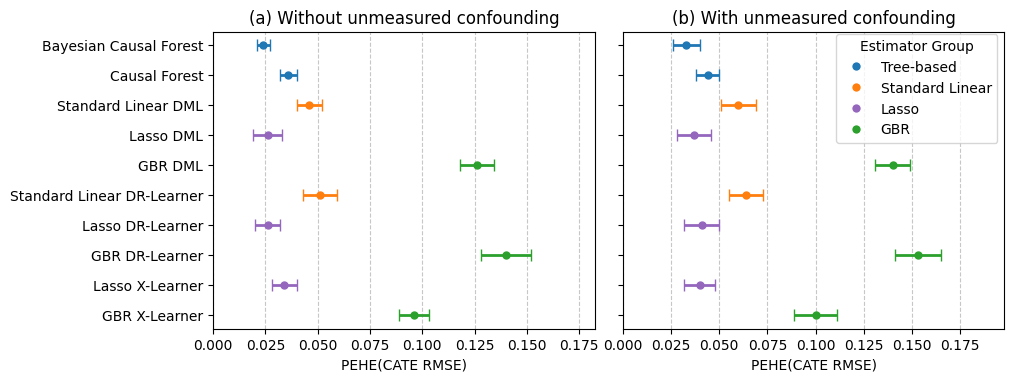

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Define estimator groups and colors
estimator_group_map = {
    "Bayesian Causal Forest": "Tree-based",
    "Causal Forest": "Tree-based",
    "Standard Linear DML": "Standard Linear",
    "Lasso DML": "Lasso",
    "GBR DML": "GBR",
    "Standard Linear DR-Learner": "Standard Linear",
    "Lasso DR-Learner": "Lasso",
    "GBR DR-Learner": "GBR",
    "Lasso X-Learner": "Lasso",
    "GBR X-Learner": "GBR"
}
group_colors = {
    "Tree-based": "#1f77b4",
    "Standard Linear": "#ff7f0e",
    "Lasso": "#9467bd",
    "GBR": "#2ca02c"
}

def plot_forest_subplot(ax, df, mean_col, sd_col, xlabel, title, group_map, color_map):
    estimators = df["Estimator"]
    y = np.arange(len(estimators)-1, -1, -1)
    means = df[mean_col]
    sds = df[sd_col]
    groups = estimators.map(group_map)
    colors = groups.map(color_map)

    for i, (mean, sd, color) in enumerate(zip(means, sds, colors)):
        ax.errorbar(mean, y[i], xerr=sd, fmt='o', markersize=5, capsize=4, elinewidth=2, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels(estimators)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_xlim(left=0, right=max(means + sds) * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

cate_rmse_plot_unbiased = time_coverage[["Estimator", "cate_rmse_mean", "cate_rmse_sd"]]
cate_rmse_plot_biased = time_coverage_biased[["Estimator", "cate_rmse_mean", "cate_rmse_sd"]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)  # smaller figure size

plot_forest_subplot(
    axes[0],
    cate_rmse_plot_unbiased,
    mean_col="cate_rmse_mean",
    sd_col="cate_rmse_sd",
    xlabel="PEHE(CATE RMSE)",
    title="(a) Without unmeasured confounding",
    group_map=estimator_group_map,
    color_map=group_colors
)

plot_forest_subplot(
    axes[1],
    cate_rmse_plot_biased,
    mean_col="cate_rmse_mean",
    sd_col="cate_rmse_sd",
    xlabel="PEHE(CATE RMSE)",
    title="(b) With unmeasured confounding",
    group_map=estimator_group_map,
    color_map=group_colors
)

handles = [plt.Line2D([0], [0], marker='o', color='w', label=grp, markerfacecolor=clr, markersize=7) for grp, clr in group_colors.items()]
#fig.legend(handles=handles, title="Estimator Group", loc="lower center", ncol=len(group_colors), bbox_to_anchor=(0.5, -0.05))
fig.legend(handles=handles, title="Estimator Group", loc="upper right", bbox_to_anchor=(0.997, 0.95))

plt.tight_layout(rect=[0, 0.08, 1, 1], pad=0.2)  # less vertical space
#plt.subplots_adjust(wspace=0.3, hspace=0.1)  # less horizontal space
plt.show()

# save as vector pdf
fig.savefig(output_figure + "cate_rmse.pdf", format="pdf", bbox_inches="tight")

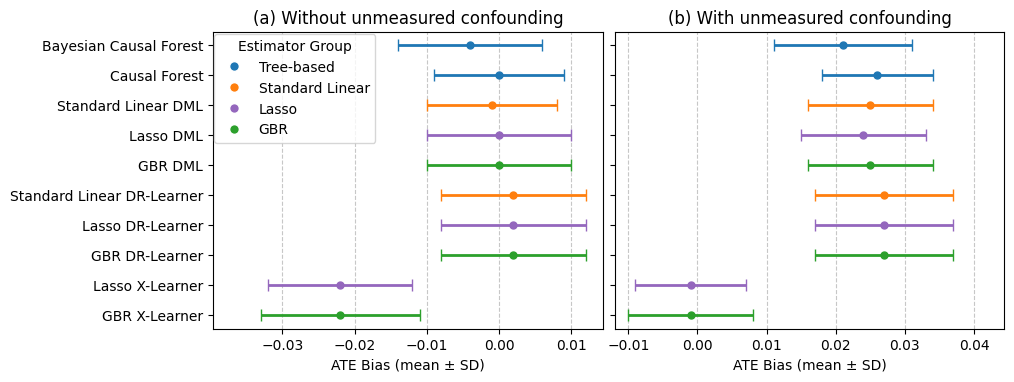

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Define estimator groups and colors
estimator_group_map = {
    "Bayesian Causal Forest": "Tree-based",
    "Causal Forest": "Tree-based",
    "Standard Linear DML": "Standard Linear",
    "Lasso DML": "Lasso",
    "GBR DML": "GBR",
    "Standard Linear DR-Learner": "Standard Linear",
    "Lasso DR-Learner": "Lasso",
    "GBR DR-Learner": "GBR",
    "Lasso X-Learner": "Lasso",
    "GBR X-Learner": "GBR"
}
group_colors = {
    "Tree-based": "#1f77b4",
    "Standard Linear": "#ff7f0e",
    "Lasso": "#9467bd",
    "GBR": "#2ca02c"
}

def plot_forest_subplot(ax, df, mean_col, sd_col, xlabel, title, group_map, color_map):
    estimators = df["Estimator"]
    y = np.arange(len(estimators)-1, -1, -1)
    means = df[mean_col]
    sds = df[sd_col]
    groups = estimators.map(group_map)
    colors = groups.map(color_map)

    for i, (mean, sd, color) in enumerate(zip(means, sds, colors)):
        ax.errorbar(mean, y[i], xerr=sd, fmt='o', markersize=5, capsize=4, elinewidth=2, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels(estimators)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_xlim(left=min(means - sds) * 1.2 if min(means - sds) < 0 else 0, right=max(means + sds) * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

ate_bias_plot_unbiased = time_coverage[["Estimator", "ate_bias_mean", "ate_bias_sd"]]
ate_bias_plot_biased = time_coverage_biased[["Estimator", "ate_bias_mean", "ate_bias_sd"]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)  # smaller figure size

plot_forest_subplot(
    axes[0],
    ate_bias_plot_unbiased,
    mean_col="ate_bias_mean",
    sd_col="ate_bias_sd",
    xlabel="ATE Bias (mean ± SD)",
    title="(a) Without unmeasured confounding",
    group_map=estimator_group_map,
    color_map=group_colors
)

plot_forest_subplot(
    axes[1],
    ate_bias_plot_biased,
    mean_col="ate_bias_mean",
    sd_col="ate_bias_sd",
    xlabel="ATE Bias (mean ± SD)",
    title="(b) With unmeasured confounding",
    group_map=estimator_group_map,
    color_map=group_colors
)

handles = [plt.Line2D([0], [0], marker='o', color='w', label=grp, markerfacecolor=clr, markersize=7) for grp, clr in group_colors.items()]
#fig.legend(handles=handles, title="Estimator Group", loc="lower center", ncol=len(group_colors), bbox_to_anchor=(0.5, -0.05))
fig.legend(handles=handles, title="Estimator Group", loc="upper left", bbox_to_anchor=(0.2, 0.95))

plt.tight_layout(rect=[0, 0.08, 1, 1], pad=0.2)
plt.show()

fig.savefig(output_figure + "ate_bias.pdf", format="pdf", bbox_inches="tight")

In [0]:
# create CATE figure against age for each estimator
## finished in the script under notebooks/cate